In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

In [68]:
def explore_column(df, col):
    """
    Explore a single column in a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to explore.
    col (str): The column name to explore.
    
    Returns:
    None
    """
    # Check if the column exists in the DataFrame
    if col not in df.columns:
        print(f"Column '{col}' does not exist in the DataFrame.")
        return

    # Display basic statistics
    print(f"Statistics for column '{col}':")
    print(df[col].describe())
    print("\n")


    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    if df[col].nunique() < 10:
        print(f"Unique values in '{col}': {df[col].unique()}")
    else:
        print(f"First 10 unique values in '{col}': {df[col].unique()[:10]}")
    print("\n")
    
    # Display missing values
    missing_values = df[col].isnull().sum()
    print(f"Missing values in '{col}': {missing_values}")
    print(f"Percentage of missing values in '{col}': {missing_values / len(df) * 100:.2f}%")


            
    # Plot the distribution of the column
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [69]:
df = pd.read_csv('data/training_set_VU_DM.csv')
df["date_time"] = pd.to_datetime(df["date_time"])


Statistics for column 'booking_bool':
count    4.958347e+06
mean     2.791051e-02
std      1.647165e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: booking_bool, dtype: float64


Number of unique values in 'booking_bool': 2
Unique values in 'booking_bool': [0 1]


Missing values in 'booking_bool': 0
Percentage of missing values in 'booking_bool': 0.00%


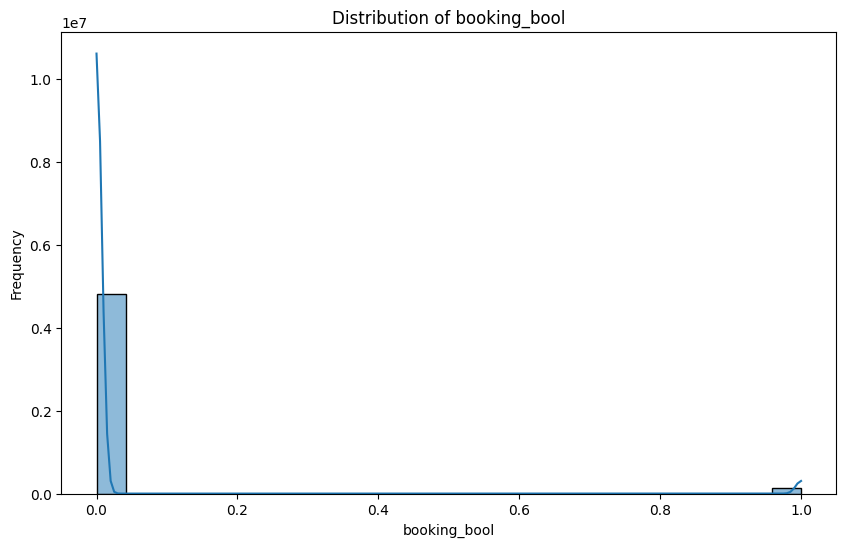

In [70]:
explore_column(df, "booking_bool")

In [71]:
df_numeric = df.select_dtypes(include=[np.number])

# Remove the target variable from the numeric dataframe

In [72]:
# train-test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=["booking_bool", "click_bool", "gross_bookings_usd", "srch_id", "date_time", "position"])
y1 = df["booking_bool"]
y2 = df["click_bool"]
y3 = df["gross_bookings_usd"]
X_train, X_test, y_train, y_test = train_test_split(X, y1, test_size=0.2, random_state=42)
X_train, X_test, y_train2, y_test2 = train_test_split(X, y2, test_size=0.2, random_state=42)
# X_train, X_test, y_train3, y_test3 = train_test_split(X, y3, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3966677, 48)
X_test shape: (991670, 48)
y_train shape: (3966677,)
y_test shape: (991670,)


In [73]:

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train,
)


# Train the model
model_book = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_click = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# Fit the model
model_book.fit(X_train, y_train, sample_weight=sample_weights)
model_click.fit(X_train, y_train2, sample_weight=sample_weights)



/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:02:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/urbansirca/miniconda3/envs/datascience/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:03:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

                Model  Accuracy  F1 Score  Precision    Recall   ROC AUC
0  Booking Bool Model  0.683924  0.112369   0.060979  0.714543  0.698793
1    Click Bool Model  0.670697  0.127335   0.072246  0.536189  0.606598


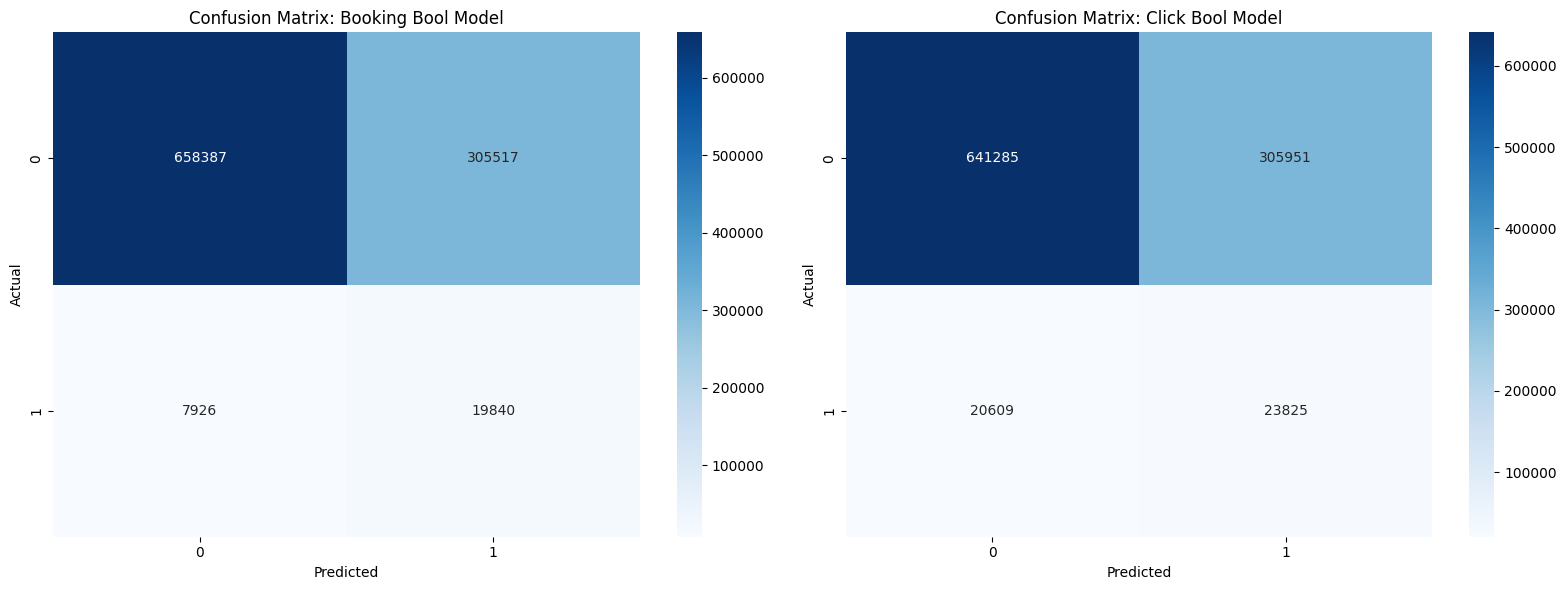

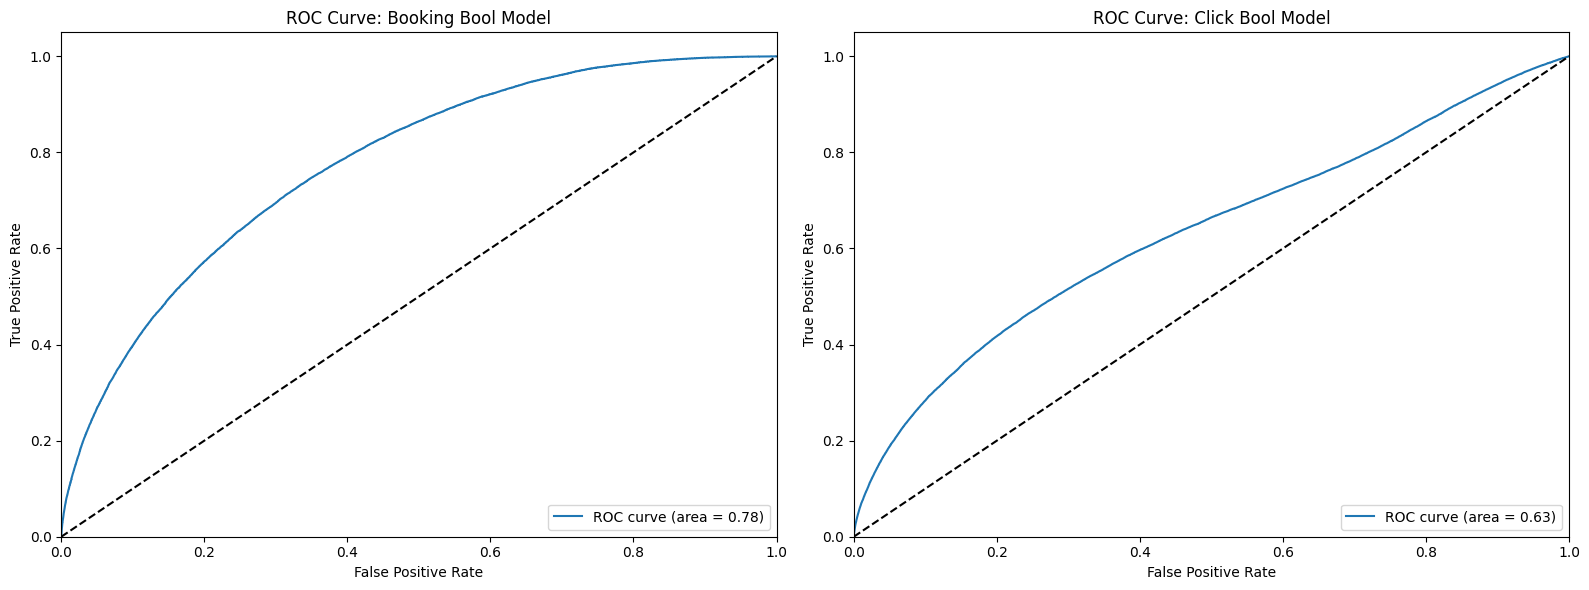

/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_84547/2865987714.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/f9/4f7hqdfs2fjbhkvbpghqwvd00000gn/T/ipykernel_84547/2865987714.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


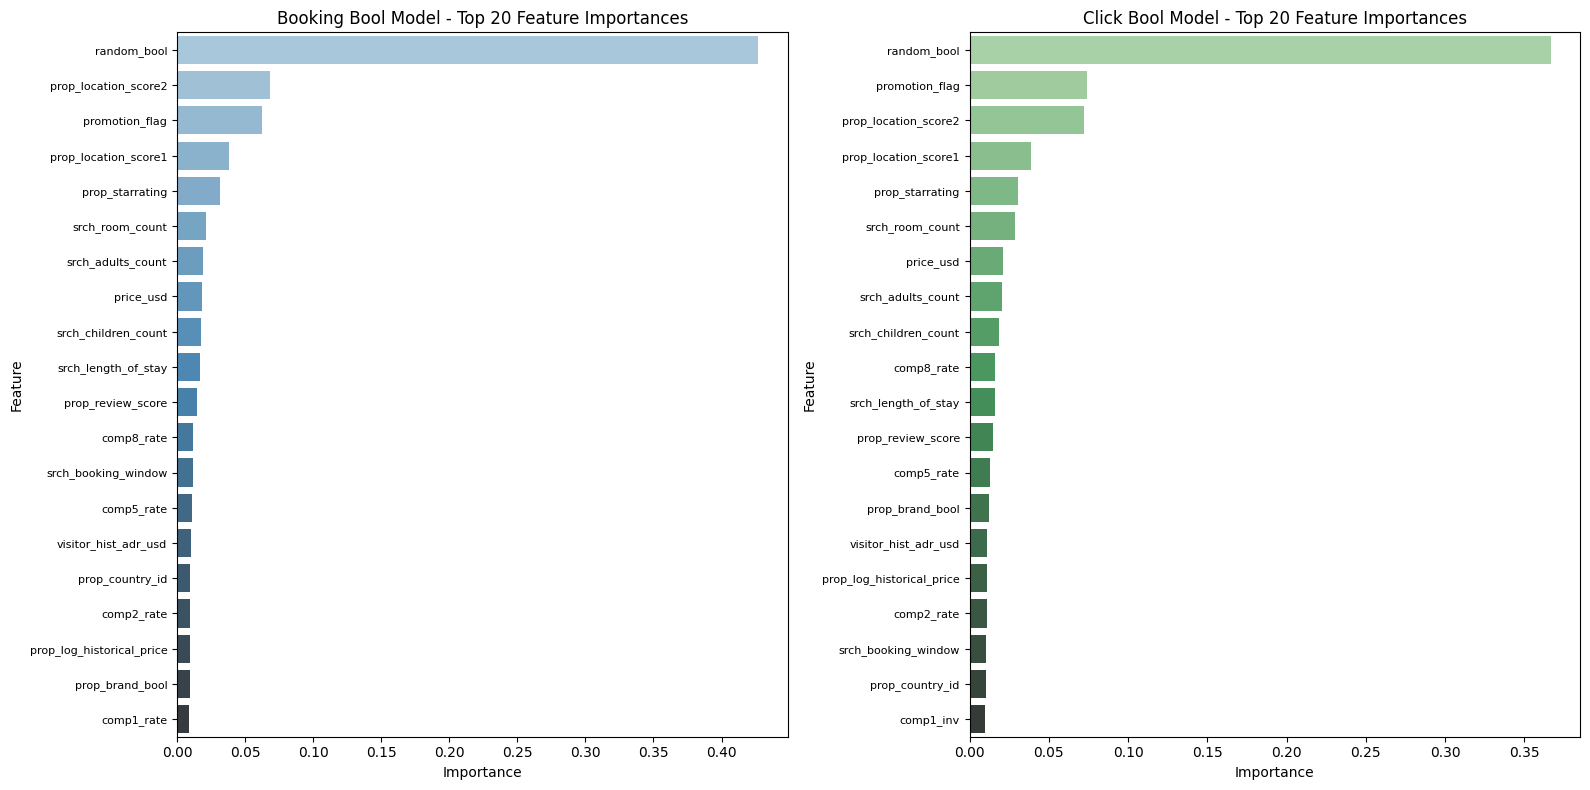

In [74]:
# Make predictions
y_pred = model_book.predict(X_test)
y_pred2 = model_click.predict(X_test)

# Evaluate the models
metrics = {
    "Model": ["Booking Bool Model", "Click Bool Model"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test2, y_pred2)],
    "F1 Score": [f1_score(y_test, y_pred), f1_score(y_test2, y_pred2)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test2, y_pred2)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test2, y_pred2)],
    "ROC AUC": [roc_auc_score(y_test, y_pred), roc_auc_score(y_test2, y_pred2)],
}

# Print metrics
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Confusion Matrix: Booking Bool Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test2, y_pred2), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix: Click Bool Model")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Plot ROC curves side by side
y_pred_proba_book = model_book.predict_proba(X_test)[:, 1]
y_pred_proba_click = model_click.predict_proba(X_test)[:, 1]

fpr_book, tpr_book, _ = roc_curve(y_test, y_pred_proba_book)
fpr_click, tpr_click, _ = roc_curve(y_test2, y_pred_proba_click)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(fpr_book, tpr_book, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba_book))
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Booking Bool Model')
axes[0].legend(loc='lower right')

axes[1].plot(fpr_click, tpr_click, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test2, y_pred_proba_click))
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve: Click Bool Model')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Feature importance
importance_book = model_book.feature_importances_
importance_click = model_click.feature_importances_
feature_names = X.columns
importance_df_book = pd.DataFrame(importance_book, index=feature_names, columns=["Importance"]).sort_values(by="Importance", ascending=False)
importance_df_click = pd.DataFrame(importance_click, index=feature_names, columns=["Importance"]).sort_values(by="Importance", ascending=False)


# Prepare sorted DataFrames for top features (make feature names a column)
feat_imp_book = (
  importance_df_book
  .sort_values("Importance", ascending=False)
  .head(20)
  .reset_index()
  .rename(columns={'index':'Feature'})
)

feat_imp_click = (
  importance_df_click
  .sort_values("Importance", ascending=False)
  .head(20)
  .reset_index()
  .rename(columns={'index':'Feature'})
)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    x="Importance", y="Feature",
    data=feat_imp_book,
    ax=axes[0], palette="Blues_d"
)
axes[0].set_title("Booking Bool Model - Top 20 Feature Importances")
axes[0].tick_params(axis="y", labelsize=8)

sns.barplot(
    x="Importance", y="Feature",
    data=feat_imp_click,
    ax=axes[1], palette="Greens_d"
)
axes[1].set_title("Click Bool Model - Top 20 Feature Importances")
axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()
